597 cells flagged for filtering out using attribute RNA_nCounts



461 cells flagged for filtering out using attribute RNA_nFeatures



612 cells flagged for filtering out using attribute RNA_percentMito



Calculating summary statistics



Using cached feature stats for cell_key I



Using existing corrected dispersion values



Calculating HVGs



500 genes marked as HVGs



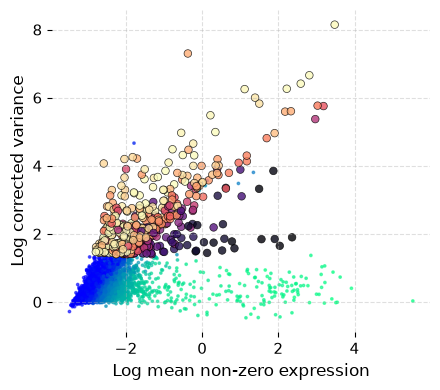

make_graph step 1/7: normalize expression matrix (computing)



make_graph step 1/7: normalize expression matrix finished in 0.4s (computing)



make_graph step 2/7: normalization statistics (computing)



make_graph step 2/7: normalization statistics finished in 0.0s (computing)



make_graph step 3/7: dimension reduction, ANN index, and kmeans (computing)



...

make_graph step 7/7: finalize graph metadata (computing)



make_graph step 7/7: finalize graph metadata finished in 0.0s (computing)



make_graph finished in 9.3s (7/7 steps, 9.2s in logged steps)



Training UMAP:   0%|                                                                                          …

Saved marker results to RNA/markers/I__RNA_leiden_cluster in 0.2s (10 clusters, layout=compact_v2)



In [1]:
import scarf
import scarf.plotting as splt
import numpy as np

scarf.fetch_dataset(
    "tenx_5K_pbmc_rnaseq",
    save_path="scarf_datasets",
    as_zarr=True,
)
ds = scarf.DataStore(
    "scarf_datasets/tenx_5K_pbmc_rnaseq/data.zarr",
    nthreads=4,
    min_features_per_cell=10,
)
ds.filter_cells(
    attrs=["RNA_nCounts", "RNA_nFeatures", "RNA_percentMito"],
    highs=[15000, 4000, 15],
    lows=[1000, 500, 0],
    reset_previous=True,
)
ds.mark_hvgs(min_cells=20, top_n=500)
ds.make_graph(feat_key="hvgs", k=11, dims=15, n_centroids=100)
ds.run_umap(n_epochs=150, spread=5, min_dist=1, parallel=True)
ds.run_leiden_clustering(resolution=0.5)
ds.run_marker_search(group_key="RNA_leiden_cluster", gene_batch_size=100)

In [2]:
markers = ds.get_markers(
    group_key="RNA_leiden_cluster",
    group_id="1",
    min_score=-1,
    min_frac_exp=-1,
)
markers.head(10)

,group_id,feature_name,score,mean,mean_rest,frac_exp,frac_exp_rest,fold_change,p_value,feature_index
0,1,ADTRP,0.63735,0.04209,0.00253,0.23982,0.01819,16.65120,3.978681e-115,4118
1,1,TSHZ2,0.60998,0.07359,0.00894,0.33282,0.04168,8.23648,5.086389e-138,11958
2,1,ANKRD55,0.58411,0.02175,0.00090,0.14835,0.00720,24.04471,2.254761e-76,3609
3,1,CHRM3-AS2,0.51966,0.06741,0.00749,0.38125,0.05381,9.00329,4.170388e-156,1366
4,1,AC005842.1,0.51202,0.02518,0.00251,0.15911,0.01781,10.04141,2.990642e-65,8111
5,1,TCEA3,0.51109,0.03161,0.00379,0.20984,0.03031,8.33439,1.394313e-78,213
6,1,CMTM8,0.48864,0.04742,0.00878,0.30592,0.06707,5.39966,7.543586e-93,2406
7,1,FHIT,0.48300,0.14135,0.01297,0.60876,0.09132,10.89459,8.430365e-285,2632
8,1,MAL,0.45094,0.18676,0.02926,0.68101,0.14437,6.38204,3.168063e-266,1774
9,1,DPYSL4,0.44754,0.01396,0.00053,0.10146,0.00417,26.51694,3.349421e-53,8071


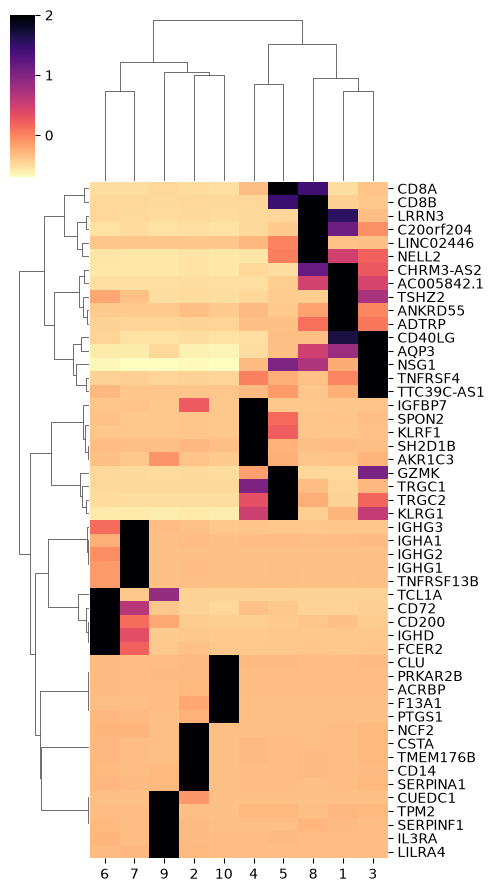

In [3]:
splt.marker_heatmap(
    ds,
    group_key="RNA_leiden_cluster",
    topn=5,
    figsize=(5, 9),
)

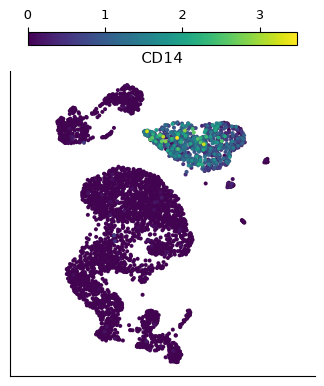

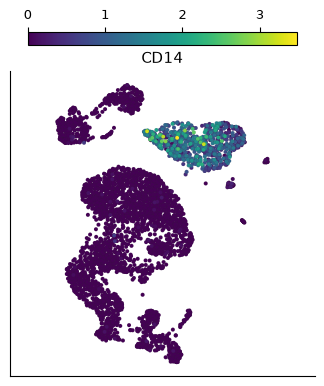

In [4]:
splt.embedding(
    ds,
    layout_key="RNA_UMAP",
    color_by="CD14",
    sort_values=True,
    show=False,
).figure

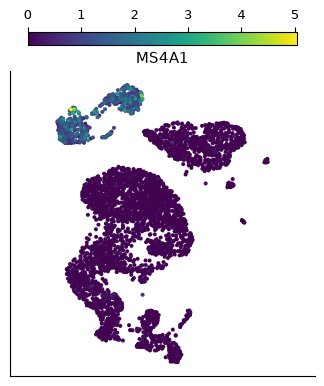

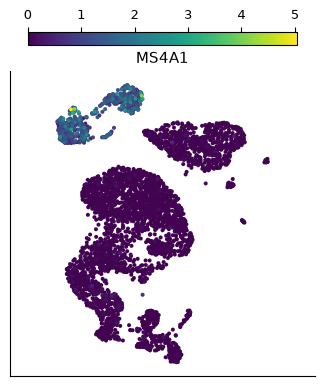

In [5]:
splt.embedding(
    ds,
    layout_key="RNA_UMAP",
    color_by="MS4A1",
    sort_values=True,
    show=False,
).figure

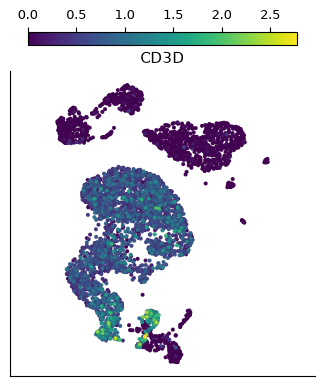

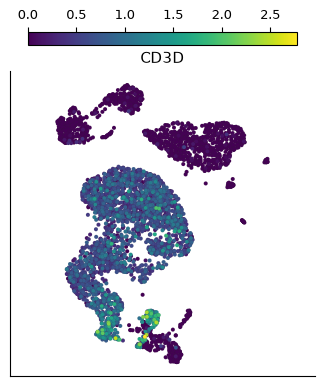

In [6]:
splt.embedding(
    ds,
    layout_key="RNA_UMAP",
    color_by="CD3D",
    sort_values=True,
    show=False,
).figure

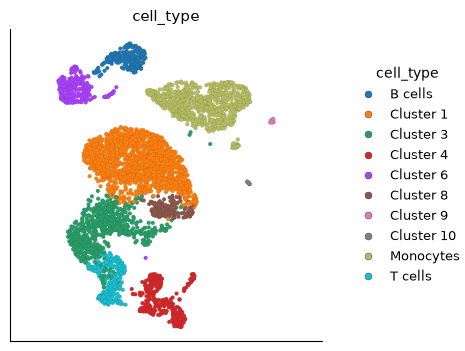

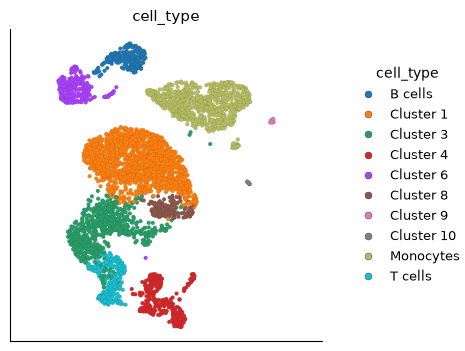

In [7]:
cluster_ids = ds.cells.fetch_all("RNA_leiden_cluster")
unique = sorted(
    {str(c) for c in cluster_ids},
    key=lambda x: (0, int(x)) if x.isdigit() else (1, x),
)


def best_cluster_for_gene(gene: str) -> str | None:
    best_cid, best_score = None, -1.0
    for cid in unique:
        table = ds.get_markers(
            group_key="RNA_leiden_cluster",
            group_id=cid,
            min_score=-1,
            min_frac_exp=-1,
        )
        name_col = "feature_name" if "feature_name" in table.columns else "names"
        hit = table[table[name_col].astype(str) == gene]
        if hit.empty:
            continue
        score = float(hit["score"].iloc[0]) if "score" in hit.columns else 0.0
        if score > best_score:
            best_cid, best_score = cid, score
    return best_cid


label_map = {c: f"Cluster {c}" for c in unique}
for gene, name in [("CD14", "Monocytes"), ("MS4A1", "B cells"), ("CD3D", "T cells")]:
    cid = best_cluster_for_gene(gene)
    if cid is not None:
        label_map[cid] = name

labels = np.array([label_map[str(c)] for c in cluster_ids], dtype=object)
ds.cells.insert(column_name="cell_type", values=labels, overwrite=True)
splt.embedding(
    ds,
    layout_key="RNA_UMAP",
    color_by="cell_type",
).figure

Calculating summary statistics



(RNA) feature stats block 1/102: read 0.0s (r2) compute 0.0s rss 738 MiB



(RNA) feature stats block 2/102: read 0.0s (ram) compute 0.0s rss 738 MiB



(RNA) feature stats block 3/102: read 0.0s (ram) compute 0.0s rss 738 MiB



(RNA) feature stats block 4/102: read 0.0s (ram) compute 0.0s rss 738 MiB



...

(RNA) feature stats block 101/102: read 0.0s (ram) compute 0.0s rss 738 MiB



(RNA) feature stats block 102/102: read 0.0s (ram) compute 0.0s rss 738 MiB



Calculating HVGs



500 genes marked as HVGs



/home/parashar/scarf/scarf/plots.py:248: RuntimeWarning: divide by zero encountered in log2
  nzm = np.log2(nzm)
/home/parashar/scarf/scarf/plots.py:249: RuntimeWarning: divide by zero encountered in log2
  fv = np.log2(fv)


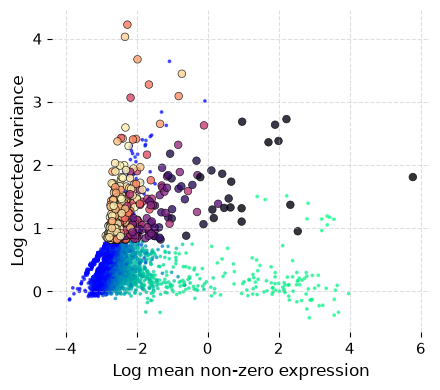

make_graph step 1/7: normalize expression matrix (computing)



make_graph step 1/7: normalize expression matrix finished in 0.3s (computing)



make_graph step 2/7: normalization statistics (computing)



make_graph step 2/7: normalization statistics finished in 0.0s (computing)



make_graph step 3/7: dimension reduction, ANN index, and kmeans (computing)



...

ANN recall: 99.85%



make_graph step 7/7: finalize graph metadata (computing)



make_graph step 7/7: finalize graph metadata finished in 0.0s (computing)



make_graph finished in 0.7s (7/7 steps, 0.7s in logged steps)



Training UMAP:   0%|                                                                                          …

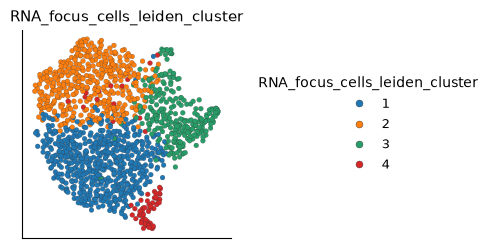

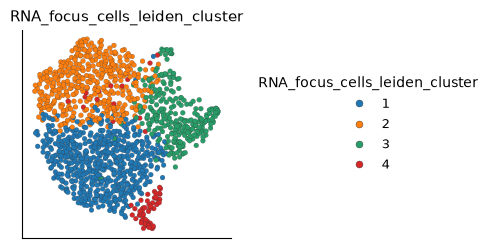

In [8]:
clusters = ds.cells.to_pandas_dataframe(
    columns=["RNA_leiden_cluster"],
    key="I",
)["RNA_leiden_cluster"].astype(str)
focus = str(clusters.value_counts().index[0])
subset = np.array([str(c) == focus for c in ds.cells.fetch_all("RNA_leiden_cluster")])
active = ds.cells.fetch_all("I").astype(bool)
ds.cells.insert("focus_cells", active & subset, overwrite=True)
# Feature keys are resolved as <cell_key>__<feat_key>. Recompute HVGs for the subset.
ds.mark_hvgs(cell_key="focus_cells", min_cells=10, top_n=500)

ds.make_graph(
    cell_key="focus_cells",
    feat_key="hvgs",
    k=11,
    dims=15,
    n_centroids=50,
)
ds.run_umap(
    cell_key="focus_cells",
    n_epochs=100,
    spread=5,
    min_dist=1,
    parallel=True,
    label="UMAP",
)
ds.run_leiden_clustering(
    cell_key="focus_cells",
    resolution=0.4,
    label="leiden_cluster",
)
# With cell_key != 'I', columns are RNA_<cell_key>_<label>
splt.embedding(
    ds,
    layout_key="RNA_focus_cells_UMAP",
    color_by="RNA_focus_cells_leiden_cluster",
    cell_key="focus_cells",
    show=False,
).figure